In [1]:
import numpy as np
import h5py


fn = "image1-competition.hdf5"

with h5py.File(fn, "r") as f:
    data = np.array(f["data"])
    wns = np.array(f["wns"])
    tissue_mask = np.array(f["tissue_mask"])
    classes = np.array(f["classes"])

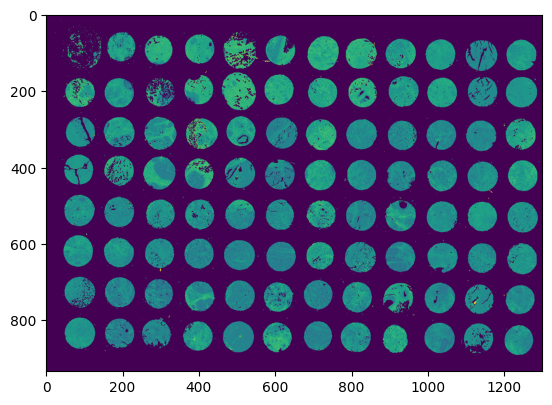

In [2]:
# display the whole image

import matplotlib.pyplot as plt

def nearest_ind(a, v):
    return np.abs(a - v).argmin()

im = data[:, :, nearest_ind(wns, 1560)]
plot = plt.imshow(im, vmin=0, vmax=1)

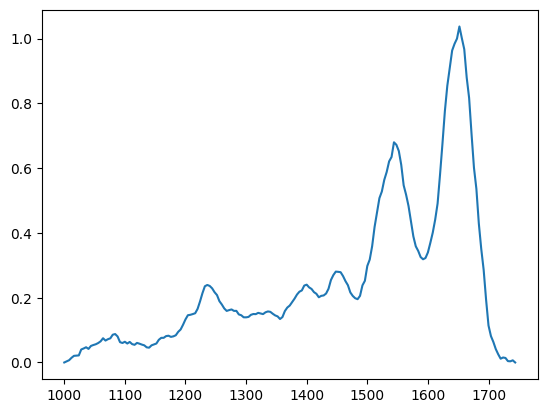

In [3]:
# a single "pixel" is a spectrum
plt.plot(wns, data[600, 200])
plt.show()

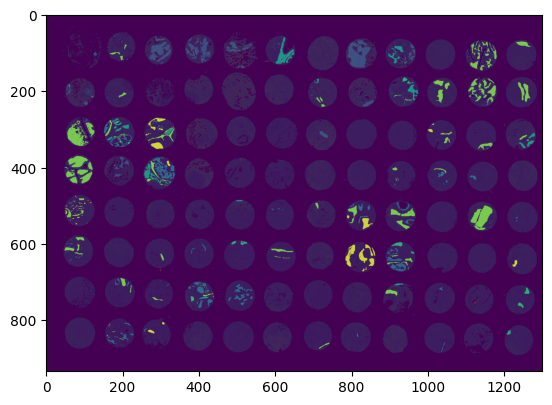

In [4]:
# the classes
plt.imshow(data[:, :, nearest_ind(wns, 1560)], vmin=0, vmax=1)
plt.imshow(classes[:, :], alpha=0.8)

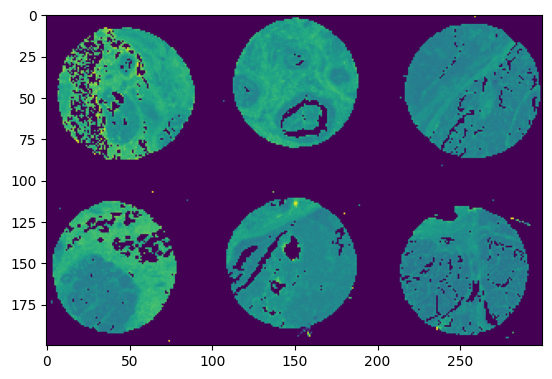

In [5]:
data_predict = data[265:465,360:660]
plt.imshow(data_predict[:, :, nearest_ind(wns, 1560)], vmin=0, vmax=1)

In [6]:
# stronger spectral-only baseline: StandardScaler + PCA + RBF SVM

annotated_sel = classes != -1
X = data[annotated_sel]
y = classes[annotated_sel]

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# 1) standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) PCA for denoising + faster SVM
# try 32 components first; later we can test 16, 32, 64
pca = PCA(n_components=32, whiten=False, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("PCA shape:", X_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

# 3) RBF SVM
# probability=True is needed because submission expects class probabilities
svm = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm.fit(X_pca, y)
print("Model trained.")

Original shape: (40145, 187)
PCA shape: (40145, 32)
Explained variance ratio sum: 0.9744625
Model trained.


In [7]:
# prediction for competition rectangle

lin_data_predict = data_predict.reshape(-1, data_predict.shape[-1])

# use the same scaler and PCA as for training
lin_data_predict_scaled = scaler.transform(lin_data_predict)
lin_data_predict_pca = pca.transform(lin_data_predict_scaled)

lin_pred = svm.predict_proba(lin_data_predict_pca)

pred = lin_pred.reshape(data_predict.shape[:2] + (lin_pred.shape[-1],))

with open("svm_pca.npy", "wb") as f:
    np.save(f, pred.astype(np.float32))

print("Saved:", pred.shape, pred.dtype)

Saved: (200, 300, 6) float64
